<a href="https://colab.research.google.com/github/yatin299/ML-LAB/blob/KNN/KNN_Problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

randomized preview (first 5 rows):
   sepal_length  sepal_width  petal_length  petal_width     species
0      5.684089     2.995364      5.077354     1.788020   virginica
1      5.289359     3.018669      4.351520     1.516120  versicolor
2      4.835152     3.529062      1.072619     0.300586      setosa
3      5.569220     3.045268      4.490836     1.486064  versicolor
4      4.726113     2.459661      4.531407     1.640195   virginica 

classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       1.00      0.91      0.95        11
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

accuracy: 0.9737


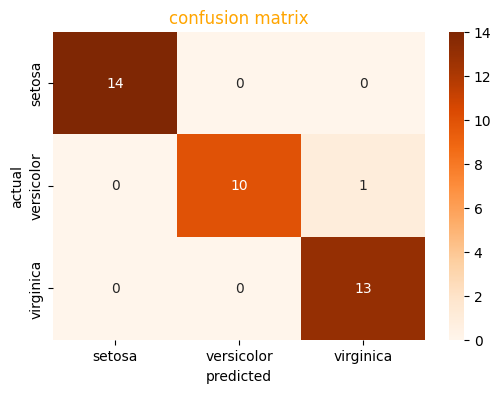

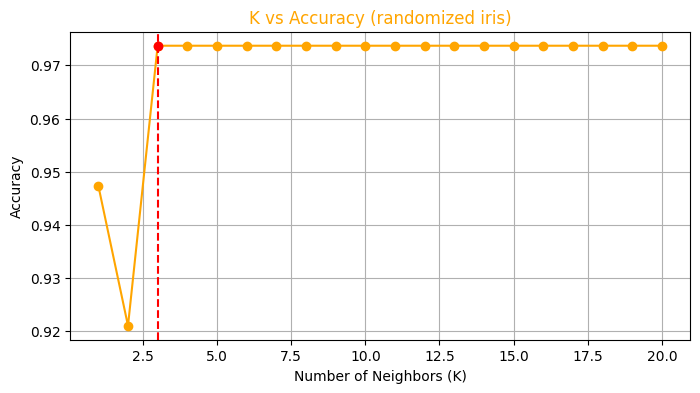


Distances (first 5 rows):
   sepal_length  sepal_width  petal_length  petal_width     species  Distance
0      5.684089     2.995364      5.077354     1.788020   virginica  4.005234
1      5.289359     3.018669      4.351520     1.516120  versicolor  3.190415
2      4.835152     3.529062      1.072619     0.300586      setosa  0.469884
3      5.569220     3.045268      4.490836     1.486064  versicolor  3.336144
4      4.726113     2.459661      4.531407     1.640195   virginica  3.524331

nearest neighbor indices (in randomized dataset): [87, 14, 51, 38, 107]


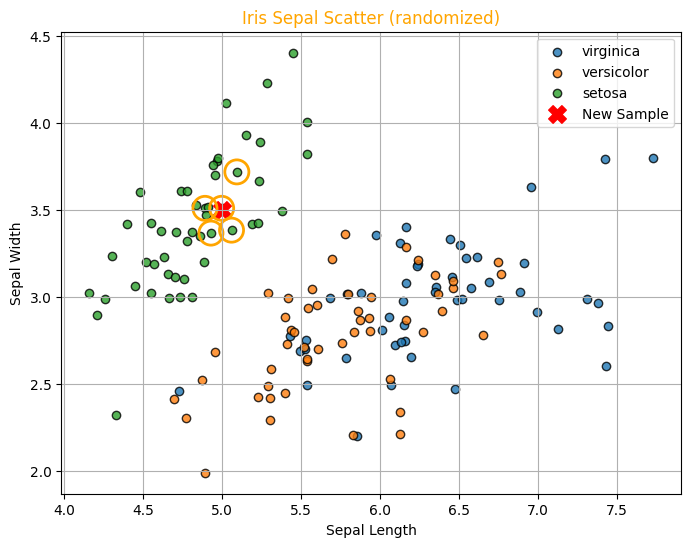

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
data = pd.read_csv(url)

seed = 7
np.random.seed(seed)

# create a randomized version: shuffle rows, scale each numeric column by a tiny random factor and add small gaussian noise
data_rand = data.sample(frac=1, random_state=seed).reset_index(drop=True)
num_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
for col in num_cols:
    factor = np.random.uniform(0.96, 1.04)         # tiny scale tweak
    noise = np.random.normal(0, 0.06 * data_rand[col].std(), size=len(data_rand))
    data_rand[col] = data_rand[col] * factor + noise

print("randomized preview (first 5 rows):")
print(data_rand.head(), "\n")

X = data_rand[num_cols]
y = data_rand['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=seed)

k = 7
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print("classification report:\n", classification_report(y_test, y_pred))
acc = accuracy_score(y_test, y_pred)
print("accuracy:", round(acc, 4))

cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title("confusion matrix", color="orange")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

# K vs Accuracy (1..20) and mark best k
k_values = range(1, 21)
scores = []
for kv in k_values:
    model = KNeighborsClassifier(n_neighbors=kv)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

best_k = k_values[int(np.argmax(scores))]
best_acc = max(scores)

plt.figure(figsize=(8,4))
plt.plot(k_values, scores, marker='o', color='orange')
plt.axvline(best_k, linestyle='--', color='red')
plt.scatter([best_k], [best_acc], color='red', zorder=5)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy (randomized iris)", color="orange")
plt.grid(True)
plt.show()

# Euclidean distances from a new sample, find 5 nearest neighbours (on randomized data)
new_flower = np.array([5.0, 3.5, 1.5, 0.2])
distances = np.sqrt(((X.values - new_flower) ** 2).sum(axis=1))
data_rand['Distance'] = distances
print("\nDistances (first 5 rows):")
print(data_rand[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species', 'Distance']].head())

nearest_idx = np.argsort(distances)[:5]
print("\nnearest neighbor indices (in randomized dataset):", nearest_idx.tolist())

# scatter plot (sepal_length vs sepal_width) with new sample and highlighted nearest neighbors
plt.figure(figsize=(8,6))
species_list = data_rand['species'].unique()
palette = {'setosa':'#ff7f0e', 'versicolor':'#1f77b4', 'virginica':'#2ca02c'}
for sp in species_list:
    spd = data_rand[data_rand['species'] == sp]
    plt.scatter(spd['sepal_length'], spd['sepal_width'], label=sp, alpha=0.8, edgecolors='k')

plt.scatter(new_flower[0], new_flower[1], color='red', marker='X', s=160, label='New Sample')
for idx in nearest_idx:
    plt.scatter(data_rand.loc[idx, 'sepal_length'], data_rand.loc[idx, 'sepal_width'],
                facecolors='none', edgecolors='orange', s=300, linewidths=2)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Sepal Scatter (randomized)", color="orange")
plt.legend()
plt.grid(True)
plt.show()
